# XGBoost — CMVN Frame-Level Pipeline

Replaces the broken per-speaker MinMax normalisation with **CMVN applied per recording at frame level**, then trains XGBoost directly on the ~876k normalised frames.

Steps:
1. Load frame features (`stage_3_window_stats_filled.parquet`)
2. Apply CMVN per recording (removes speaker/channel DC offset)
3. Speaker-independent 70/15/15 split (stratified by language × gender)
4. Coarse → fine XGBoost hyperparameter search on a frame subsample (5-fold speaker-independent CV)
5. 10-fold speaker-independent CV with best params — report metrics per fold, frame, recording, language, gender
6. Held-out test set evaluation
7. Diagnostics and save

In [18]:
# Display settings 

import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.set_printoptions(suppress=True, precision=4)

In [19]:
# =============================================================================
# Cell 1 — Imports & configuration
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold, train_test_split
)
from xgboost import XGBRegressor

# --- Paths -------------------------------------------------------------------
BASE_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local")
DATA_PATH = BASE_DIR / "data" / "stage_3_window_stats_filled.parquet"
META_PATH = BASE_DIR / "data" / "tesdhe_metadata.csv"
OUT_DIR   = BASE_DIR / "outputs" / "CMVN"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Reproducibility ---------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

# --- CV / search config ------------------------------------------------------
N_FOLDS_SEARCH  = 5   # folds used during hyperparameter search
N_FOLDS_EVAL    = 10  # folds used for final evaluation CV
N_FRAMES_SEARCH = 30  # frames sampled per recording for search subsample
N_ITER          = 30  # coarse random search iterations

# Columns that are identifiers, target, or metadata — never features
NON_FEATURE_COLS = {"file_name", "frame_idx", "bpm"}
META_COLS_EXCL   = {"speaker_id", "language", "gender", "age_years"}

pd.set_option("display.float_format", "{:.4f}".format)
print("Config loaded.")

Config loaded.


In [20]:
# =============================================================================
# Cell 2 — Load frame-level data & attach metadata
# =============================================================================
frames = pd.read_parquet(DATA_PATH)
meta   = pd.read_csv(META_PATH)

print(f"Frames shape  : {frames.shape}")
print(f"Metadata shape: {meta.shape}")

meta_cols = meta[["file_name", "speaker_id", "language", "gender", "age_years"]].drop_duplicates("file_name")
frames = frames.merge(meta_cols, on="file_name", how="left")

n_null = frames["speaker_id"].isna().sum()
assert n_null == 0, f"{n_null} frames have no speaker_id after merge"

print(f"\nAfter metadata merge: {frames.shape}")
print(f"Unique recordings : {frames['file_name'].nunique()}")
print(f"Unique speakers   : {frames['speaker_id'].nunique()}")
print(f"BPM range         : {frames['bpm'].min()} – {frames['bpm'].max()}")

Frames shape  : (1252312, 95)
Metadata shape: (10034, 13)

After metadata merge: (1252312, 99)
Unique recordings : 10034
Unique speakers   : 109
BPM range         : 48 – 178


In [22]:
# =============================================================================
# Cell 3 — CMVN per recording
#
# Applies z-score normalisation (mean subtraction + std division) to each
# acoustic feature independently, grouped by recording.  This removes the
# per-recording speaker/channel DC offset while preserving temporal dynamics.
# Metadata columns (speaker_id, language, gender, age_years) are excluded.
# =============================================================================
FEATURE_COLS = [
    c for c in frames.columns
    if c not in NON_FEATURE_COLS and c not in META_COLS_EXCL
]

print(f"Acoustic feature columns : {len(FEATURE_COLS)}")
print(f"Excluded (non-feature)   : {NON_FEATURE_COLS}")
print(f"Excluded (metadata)      : {META_COLS_EXCL}")

# CMVN: per-recording z-score (acoustic features only)
frames[FEATURE_COLS] = (
    frames.groupby("file_name")[FEATURE_COLS]
    .transform(lambda x: (x - x.mean()) / max(float(x.std(ddof=0)), 1e-8))
)

# Constant features within a recording produce NaN after /std; fill with 0
n_inf = np.isinf(frames[FEATURE_COLS].values).sum()
frames[FEATURE_COLS] = frames[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
n_nan = frames[FEATURE_COLS].isna().sum().sum()
frames[FEATURE_COLS] = frames[FEATURE_COLS].fillna(0.0)
print(f"\nReplaced {n_inf} inf and {n_nan} NaN values with 0 after CMVN.")

# Sanity: spot-check per-recording mean ≈ 0, std ≈ 1
sample_recs = frames["file_name"].unique()[:3]
chk = (
    frames[frames["file_name"].isin(sample_recs)]
    .groupby("file_name")[FEATURE_COLS[:4]]
    .agg(["mean", "std"])
    .round(4)
)
print("\nPer-recording CMVN spot-check (first 4 features, 3 recordings):")
print(chk)

Acoustic feature columns : 92
Excluded (non-feature)   : {'frame_idx', 'bpm', 'file_name'}
Excluded (metadata)      : {'speaker_id', 'gender', 'age_years', 'language'}

Replaced 0 inf and 0 NaN values with 0 after CMVN.

Per-recording CMVN spot-check (first 4 features, 3 recordings):
                      mfcc_1         mfcc_2         mfcc_3         mfcc_4  \
                        mean    std    mean    std    mean    std    mean   
file_name                                                                   
En001M240401A083.ogg -0.0000 1.0165 -0.0000 1.0165  0.0000 1.0165  0.0000   
En001M240402A079.ogg -0.0000 1.0055 -0.0000 1.0055  0.0000 1.0055 -0.0000   
En001M240403A076.ogg  0.0000 1.0108 -0.0000 1.0108 -0.0000 1.0108  0.0000   

                             
                        std  
file_name                    
En001M240401A083.ogg 1.0165  
En001M240402A079.ogg 1.0055  
En001M240403A076.ogg 1.0108  


In [23]:
# =============================================================================
# Cell X — Save normalised frame-level dataset to Parquet
# =============================================================================
OUT_PATH = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm/frames_cmvn.parquet"

frames.to_parquet(OUT_PATH, index=False, engine="pyarrow")
print(f"Saved {len(frames):,} rows × {frames.shape[1]} columns → {OUT_PATH}")

Saved 1,252,312 rows × 99 columns → /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm/frames_cmvn.parquet


In [24]:
frames = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm/frames_cmvn.parquet")

In [25]:
frames.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm,speaker_id,language,gender,age_years
0,En001M240401A083.ogg,0,-0.1465,-1.8709,-0.2108,0.4912,0.1879,-0.3638,0.6411,-0.1774,0.9623,0.6599,-1.2263,0.9829,0.8023,0.9772,0.8724,1.7015,0.1804,-1.1103,0.5500,0.0869,-2.2649,-1.1102,-1.1192,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,83,1,English,M,24
1,En001M240401A083.ogg,1,-0.0980,-2.2408,1.5342,-0.0007,0.1686,0.2985,-0.1478,0.0788,0.3269,0.3205,-1.5136,0.8125,1.1124,0.7651,0.0261,0.4012,0.9529,-0.9958,-0.1756,-0.2939,-2.2649,-1.1102,-1.1192,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,83,1,English,M,24
2,En001M240401A083.ogg,2,-0.1807,-2.4483,1.4265,1.2312,0.1812,0.1940,1.5657,-0.2950,-0.6920,-0.1368,-2.1013,0.0273,1.4601,1.2937,0.1184,0.5464,0.6581,-1.7263,0.0311,1.0155,0.7083,-1.1102,-1.1192,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,83,1,English,M,24
3,En001M240401A083.ogg,3,0.0622,-2.2924,1.8433,0.9178,0.2330,-0.1852,1.1155,-0.1785,0.8266,1.1232,-1.6227,-0.1146,0.5304,1.8956,-0.5158,0.4560,2.2857,-1.0241,-0.7472,1.4101,0.6854,-1.1102,-1.1192,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000

In [26]:
# spearman correlation 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns for correlation
numeric_df = frames.select_dtypes(include=[np.number])
cor_m = numeric_df.corr(method="spearman")


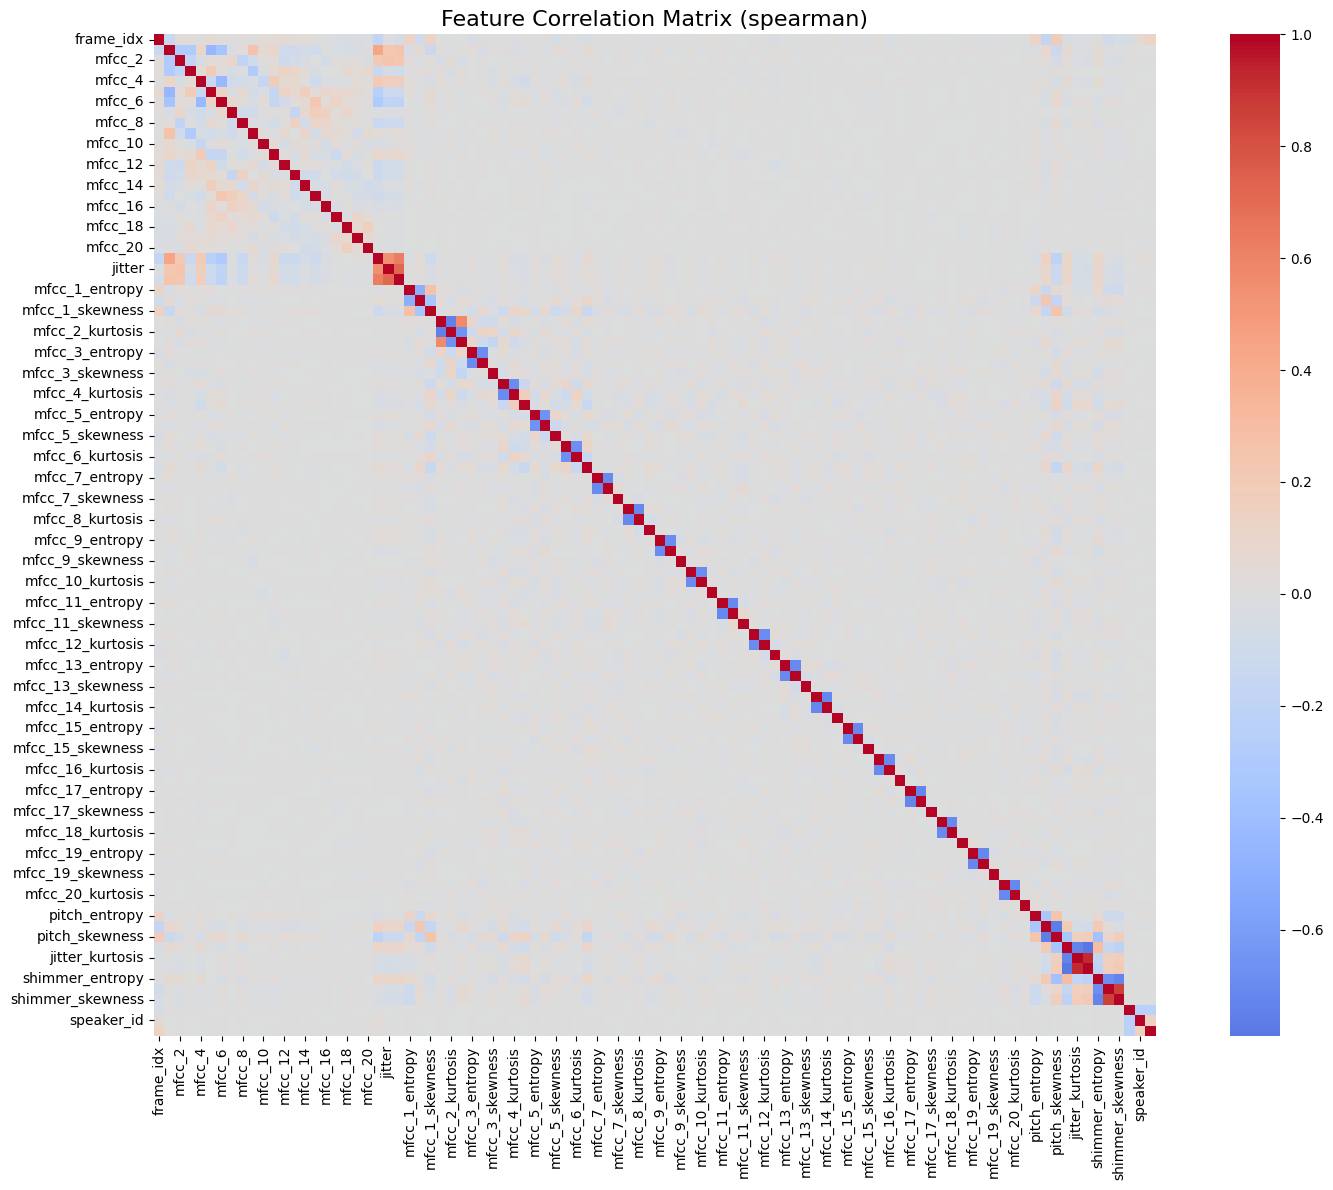

In [27]:
# Correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(cor_m, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix (spearman)", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Highest correlated feature pairs (|r| >= 0.75)
threshold = 0.75
num_cols = frames.select_dtypes(include=['int', 'float']).columns
cols = list(num_cols)  # Convert to list directly from num_cols
pairs = []

# pairwise correlations computed on the fly (no full corr matrix)
for i in range(len(cols)):
    xi = frames[cols[i]]
    if xi.nunique(dropna=True) <= 1:
        continue
    for j in range(i + 1, len(cols)):
        xj = frames[cols[j]]
        if xj.nunique(dropna=True) <= 1:
            continue
        corr = xi.corr(xj)  # spearman by default
        if pd.isna(corr):
            continue
        if abs(corr) >= threshold:
            pairs.append((cols[i], cols[j], float(corr)))

# sort by absolute correlation descending and print
pairs.sort(key=lambda t: -abs(t[2]))

total_cor = 0

print(f"\n--- Feature Correlations (|r| >= {threshold}) ---")
if pairs:
    print(f"Found {len(pairs)} correlated pairs:\n")
    for a, b, c in pairs:
        print(f"  {a:25s} <> {b:25s}: {c:+.4f}")
        total_cor += abs(c)
else:
    print(f"No variable pairs found with |corr| >= {threshold}")
print(f"Mean high correlation = |{total_cor/len(pairs)}|")
# --- Share of the dataset involved in highly correlated pairs ---
total_numeric_features = len(cols)
total_possible_pairs = total_numeric_features * (total_numeric_features - 1) // 2

# Unique features that appear in at least one highly correlated pair
features_in_pairs = set()
for a, b, _ in pairs:
    features_in_pairs.add(a)
    features_in_pairs.add(b)

pct_pairs = 100 * len(pairs) / total_possible_pairs if total_possible_pairs > 0 else 0.0
pct_features = 100 * len(features_in_pairs) / total_numeric_features if total_numeric_features > 0 else 0.0

print(f"\n--- Dataset Coverage of Highly Correlated Pairs ---")
print(f"Total numeric features:           {total_numeric_features}")
print(f"Total possible feature pairs:     {total_possible_pairs}")
print(f"Highly correlated pairs found:    {len(pairs)} ({pct_pairs:.2f}% of all pairs)")
print(f"Unique features in those pairs:   {len(features_in_pairs)} ({pct_features:.2f}% of all features)")


--- Feature Correlations (|r| >= 0.75) ---
Found 5 correlated pairs:

  jitter_kurtosis           <> jitter_skewness          : +0.9142
  shimmer_kurtosis          <> shimmer_skewness         : +0.8592
  jitter_entropy            <> jitter_skewness          : -0.7859
  mfcc_2_entropy            <> mfcc_2_kurtosis          : -0.7511
  pitch_kurtosis            <> pitch_skewness           : -0.7504
Mean high correlation = |0.8121588875550347|

--- Dataset Coverage of Highly Correlated Pairs ---
Total numeric features:           96
Total possible feature pairs:     4560
Highly correlated pairs found:    5 (0.11% of all pairs)
Unique features in those pairs:   9 (9.38% of all features)


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

meta = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")

recording_features = (
    frames.drop(columns=["frame_idx"])
      .groupby("file_name", as_index=False)
      .mean(numeric_only=True)
)

# Merge metadata
recording_features = recording_features.merge(
    meta[["file_name", "language", "response_type", "gender"]],
    on="file_name",
    how="inner"
)

recording_features = pd.DataFrame(recording_features)


In [30]:
recording_features.head()

,file_name,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm,speaker_id,age_years,language,response_type,gender
0,En001M240401A083.ogg,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,83.0000,1.0000,24.0000,English,Answering,M
1,En001M240402A079.ogg,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,79.0000,1.0000,24.0000,English,Answering,M
2,En001M240403A076.ogg,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,76.0000,1.0000,24.0000,English,Answering,M
3,En001M240404A076.ogg,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0

OHE columns created: ['lang_English', 'lang_Tamil', 'gender_F', 'gender_M', 'response_AfterVideo', 'response_Answering', 'response_Reading']


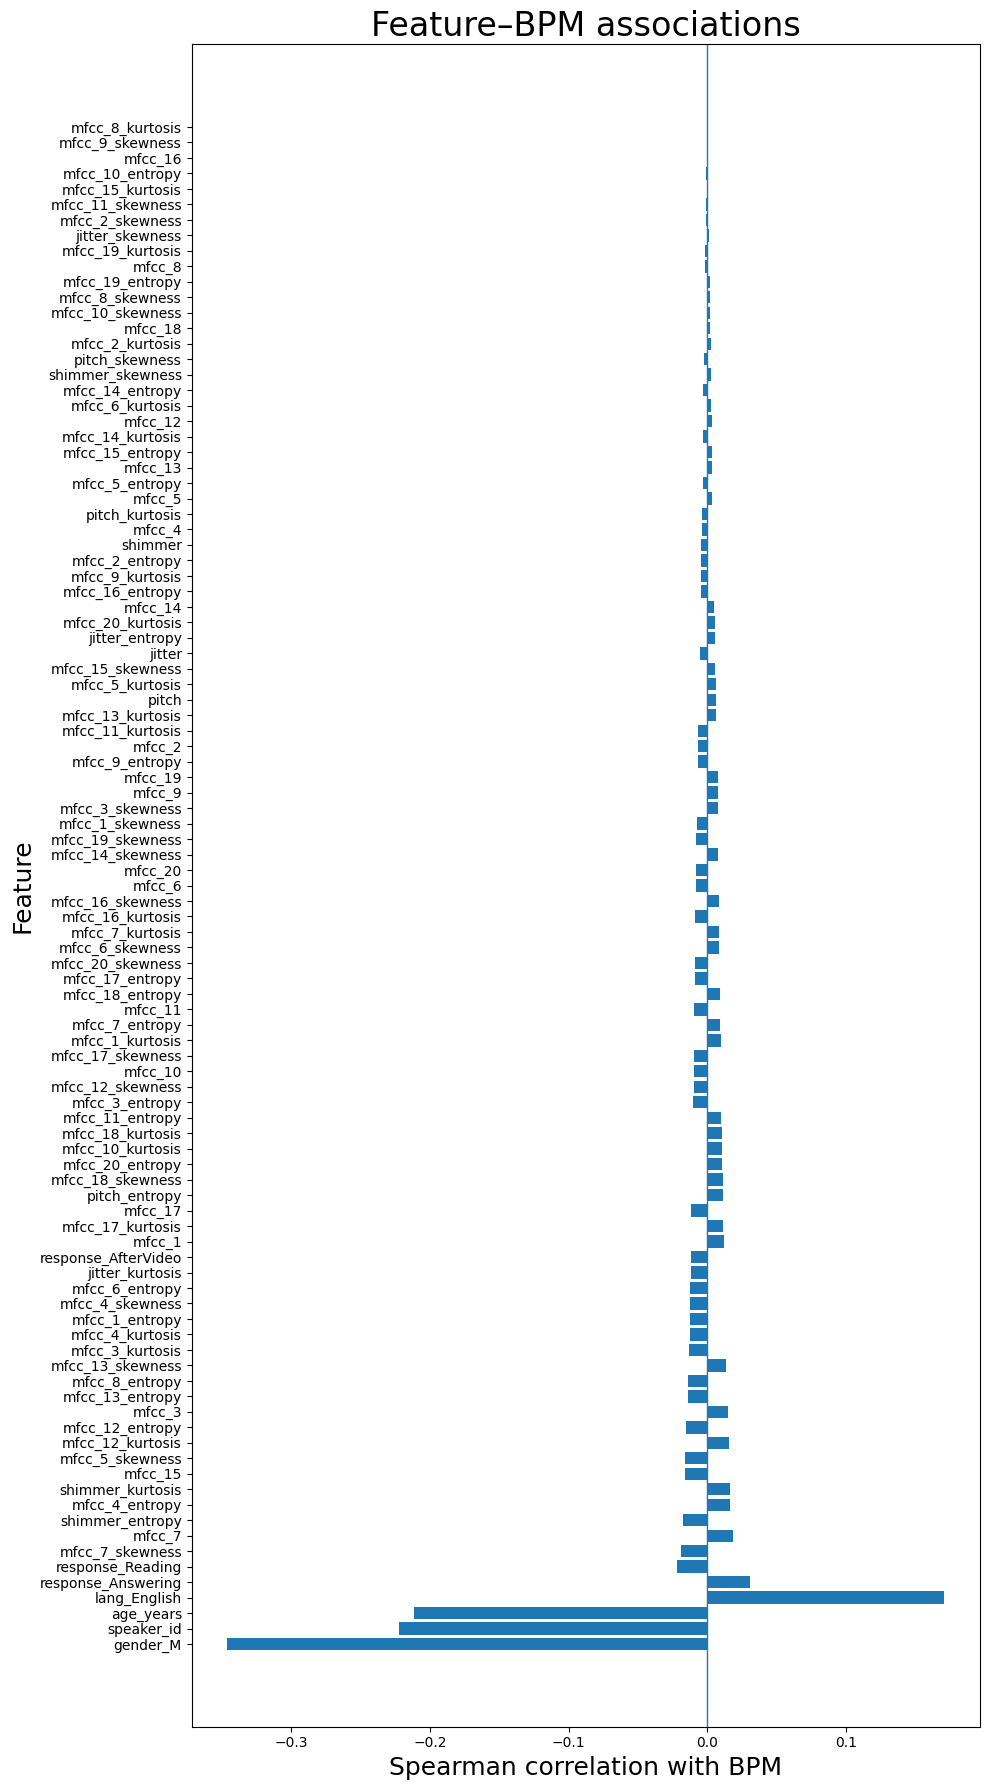

Top feature–BPM associations:
               feature  spearman_rho
95            gender_M       -0.3458
92          speaker_id       -0.2225
93           age_years       -0.2113
94        lang_English        0.1707
97  response_Answering        0.0304
98    response_Reading       -0.0218
43     mfcc_7_skewness       -0.0189
6               mfcc_7        0.0181
89     shimmer_entropy       -0.0174
32      mfcc_4_entropy        0.0165


In [31]:
import pandas as pd

# --- One-Hot Encode categorical metadata ---
# Language: binary (English/Tamil) -> one column is enough
# Gender:   binary (M/F)           -> one column is enough
# Response: 3 levels (Answering/Reading/Video) -> all three kept for interpretability
recording_features_ohe = pd.get_dummies(
    recording_features,
    columns=["language", "gender", "response_type"],
    prefix=["lang", "gender", "response"],
    drop_first=False,   # keep all levels; we drop redundant ones manually below
    dtype=float,        # so pandas' boolean dummies become 0.0/1.0 for .corr()
)

# Quick sanity check so future runs won't silently break if category labels change
print("OHE columns created:", [c for c in recording_features_ohe.columns
                               if c.startswith(("lang_", "gender_", "response_"))])

# Binary features (language, gender): drop one side of each redundant pair.
# The remaining column acts as an indicator; its sign shows direction.
# Kept: lang_English (positive corr = English associated with higher BPM)
#       gender_M     (positive corr = males associated with higher BPM)
recording_features_ohe = recording_features_ohe.drop(columns=["lang_Tamil", "gender_F"])

# Response type: keep all three columns so each bar in the plot shows
# "this response type vs. the other two combined".

# --- Feature-BPM correlation plot (unchanged logic below) ---
numeric_cols = recording_features_ohe.select_dtypes(include="number").columns.drop("bpm")

corrs = {}
for col in numeric_cols:
    valid = recording_features_ohe[[col, "bpm"]].dropna()
    corrs[col] = valid[col].corr(valid["bpm"], method="spearman")

corr_df = (
    pd.DataFrame({"feature": list(corrs.keys()), "spearman_rho": list(corrs.values())})
    .sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(10, 18))
plt.barh(corr_df["feature"], corr_df["spearman_rho"])
plt.axvline(0, linewidth=1)
plt.ylabel("Feature", fontsize=18)
plt.xlabel("Spearman correlation with BPM", fontsize=18)
plt.title("Feature–BPM associations", fontsize=24)
plt.tight_layout()
plt.show()

print("Top feature–BPM associations:")
print(corr_df.head(10))

In [32]:
temp = features.merge(metadata[["file_name", "speaker_id"]], on="file_name", how="left")
print(temp.columns.tolist())


['file_name', 'frame_idx', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'pitch', 'jitter', 'shimmer', 'mfcc_1_entropy', 'mfcc_1_kurtosis', 'mfcc_1_skewness', 'mfcc_2_entropy', 'mfcc_2_kurtosis', 'mfcc_2_skewness', 'mfcc_3_entropy', 'mfcc_3_kurtosis', 'mfcc_3_skewness', 'mfcc_4_entropy', 'mfcc_4_kurtosis', 'mfcc_4_skewness', 'mfcc_5_entropy', 'mfcc_5_kurtosis', 'mfcc_5_skewness', 'mfcc_6_entropy', 'mfcc_6_kurtosis', 'mfcc_6_skewness', 'mfcc_7_entropy', 'mfcc_7_kurtosis', 'mfcc_7_skewness', 'mfcc_8_entropy', 'mfcc_8_kurtosis', 'mfcc_8_skewness', 'mfcc_9_entropy', 'mfcc_9_kurtosis', 'mfcc_9_skewness', 'mfcc_10_entropy', 'mfcc_10_kurtosis', 'mfcc_10_skewness', 'mfcc_11_entropy', 'mfcc_11_kurtosis', 'mfcc_11_skewness', 'mfcc_12_entropy', 'mfcc_12_kurtosis', 'mfcc_12_skewness', 'mfcc_13_entropy', 'mfcc_13_kurtosis', 'mfcc_13_ske

# New

In [33]:
# =============================================================================
# Speaker-independent 70/15/15 train/validation/test split with stratification
# across language and gender. Saves speaker_id, file_name, and stratum
# alongside X/y so they can be used for grouped + stratified CV later.
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

FEATURES_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm/frames_cmvn.parquet")
METADATA_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")
OUTPUT_DIR    = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm")

# --- Load data ---------------------------------------------------------------
features = pd.read_parquet(FEATURES_PATH)
metadata = pd.read_csv(METADATA_PATH)

# --- Build a speaker-level table for stratification --------------------------
speakers = (
    metadata.groupby("speaker_id")
            .agg(language=("language", "first"),
                 gender=("gender", "first"),
                 bpm_mean=("bpm", "mean"))
            .reset_index()
)

# BPM median split per speaker — ensures similar target distributions
# across splits alongside language and gender.
speakers["bpm_group"] = pd.qcut(
    speakers["bpm_mean"], q=2, labels=["low", "high"], duplicates="drop"
)

# Composite label: 2 × 2 × 2 = up to 8 strata
speakers["stratum"] = (
    speakers["language"] + "_" + speakers["gender"] + "_" + speakers["bpm_group"].astype(str)
)

# Fall back to language+gender for any stratum with fewer than 2 members
# (can happen when a demographic group has very few speakers).
too_small = speakers["stratum"].value_counts()
too_small = too_small[too_small < 2].index
speakers.loc[speakers["stratum"].isin(too_small), "stratum"] = (
    speakers.loc[speakers["stratum"].isin(too_small), "language"] + "_" +
    speakers.loc[speakers["stratum"].isin(too_small), "gender"]
)

# --- Speaker-independent stratified split (tolerant of small strata) ---------
# Iterates over strata and assigns speakers proportionally.
# Singletons go to train; strata of 2 get one speaker each in train/val.
rng = np.random.default_rng(RANDOM_STATE)
train_ids, val_ids, test_ids = [], [], []

for _, grp in speakers.groupby("stratum"):
    ids = grp["speaker_id"].tolist()
    rng.shuffle(ids)
    n = len(ids)
    if n == 1:
        train_ids.extend(ids)
    elif n == 2:
        train_ids.append(ids[0])
        val_ids.append(ids[1])
    else:
        n_train = max(1, round(n * TRAIN_SIZE))
        n_val   = max(1, round(n * VAL_SIZE))
        train_ids.extend(ids[:n_train])
        val_ids.extend(ids[n_train : n_train + n_val])
        test_ids.extend(ids[n_train + n_val :])

train_speakers = speakers[speakers["speaker_id"].isin(train_ids)]
val_speakers   = speakers[speakers["speaker_id"].isin(val_ids)]
test_speakers  = speakers[speakers["speaker_id"].isin(test_ids)]

# --- Map speakers back to frame-level rows -----------------------------------
# frames_cmvn.parquet already carries speaker_id, language, gender from the
# CMVN step; only stratum (computed above) needs to be attached.
features = features.merge(
    speakers[["speaker_id", "stratum"]],
    on="speaker_id", how="left",
)

train_mask = features["speaker_id"].isin(train_speakers["speaker_id"])
val_mask   = features["speaker_id"].isin(val_speakers["speaker_id"])
test_mask  = features["speaker_id"].isin(test_speakers["speaker_id"])

# --- Build X / y / groups sets -----------------------------------------------
# Drop identifiers, metadata, and target from X; keep them in the groups frame.
DROP_COLS  = ["file_name", "frame_idx", "bpm",
              "speaker_id", "language", "gender", "age_years", "stratum"]
GROUP_COLS = ["speaker_id", "file_name", "language", "gender", "stratum"]

train_rows = features.loc[train_mask].reset_index(drop=True)
val_rows   = features.loc[val_mask].reset_index(drop=True)
test_rows  = features.loc[test_mask].reset_index(drop=True)

X_train, y_train, groups_train = (
    train_rows.drop(columns=[c for c in DROP_COLS if c in train_rows.columns]),
    train_rows["bpm"],
    train_rows[GROUP_COLS],
)
X_val, y_val, groups_val = (
    val_rows.drop(columns=[c for c in DROP_COLS if c in val_rows.columns]),
    val_rows["bpm"],
    val_rows[GROUP_COLS],
)
X_test, y_test, groups_test = (
    test_rows.drop(columns=[c for c in DROP_COLS if c in test_rows.columns]),
    test_rows["bpm"],
    test_rows[GROUP_COLS],
)

# --- Save to parquet ---------------------------------------------------------
X_train.to_parquet(OUTPUT_DIR / "X_train.parquet", index=False)
y_train.to_frame().to_parquet(OUTPUT_DIR / "y_train.parquet", index=False)
groups_train.to_parquet(OUTPUT_DIR / "groups_train.parquet", index=False)

X_val.to_parquet(OUTPUT_DIR / "X_val.parquet", index=False)
y_val.to_frame().to_parquet(OUTPUT_DIR / "y_val.parquet", index=False)
groups_val.to_parquet(OUTPUT_DIR / "groups_val.parquet", index=False)

X_test.to_parquet(OUTPUT_DIR / "X_test.parquet", index=False)
y_test.to_frame().to_parquet(OUTPUT_DIR / "y_test.parquet", index=False)
groups_test.to_parquet(OUTPUT_DIR / "groups_test.parquet", index=False)

# --- Quick sanity report -----------------------------------------------------
print(f"Speakers -> train: {len(train_speakers)}  "
      f"val: {len(val_speakers)}  test: {len(test_speakers)}")
print(f"Frames   -> train: {len(X_train)}  "
      f"val: {len(X_val)}  test: {len(X_test)}")
for col in ["language", "gender", "bpm_group"]:
    comparison = pd.concat(
        [train_speakers[col].value_counts().rename("train"),
         val_speakers[col].value_counts().rename("val"),
         test_speakers[col].value_counts().rename("test")],
        axis=1,
    ).fillna(0).astype(int)
    print(f"\nSpeakers per {col}:\n{comparison}")

Speakers -> train: 77  val: 16  test: 16
Frames   -> train: 868421  val: 194387  test: 189504

Speakers per language:
          train  val  test
language                  
English      57   12    11
Tamil        20    4     5

Speakers per gender:
        train  val  test
gender                  
M          40    8     9
F          37    8     7

Speakers per bpm_group:
           train  val  test
bpm_group                  
low           39    8     8
high          38    8     8


In [34]:
# =============================================================================
# XGBoost — Hyperparameter tuning on new_norm data
# Runs a coarse random search, then trains the best model on the full training
# set and saves params + model to outputs/new_norm/ for the evaluation cell.
# =============================================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from xgboost import XGBRegressor

RANDOM_STATE    = 42
N_FOLDS_SEARCH  = 5
N_ITER_COARSE   = 30
N_FRAMES_SEARCH = 30  # frames sampled per recording for the subsample

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/new_norm")
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_train_full = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train_full = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
g_train_full = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

# --- Subsample for faster search (N_FRAMES_SEARCH frames per recording) ------
rng = np.random.default_rng(RANDOM_STATE)
search_idx = []
for fn in g_train_full["file_name"].unique():
    idx = g_train_full.index[g_train_full["file_name"] == fn].tolist()
    chosen = rng.choice(idx, size=min(N_FRAMES_SEARCH, len(idx)), replace=False)
    search_idx.extend(chosen.tolist())
search_idx = sorted(search_idx)

X_s = X_train_full.iloc[search_idx].reset_index(drop=True)
y_s = y_train_full.iloc[search_idx].reset_index(drop=True)
g_s = g_train_full.iloc[search_idx].reset_index(drop=True)

bpm_tertile = pd.qcut(y_train_full, q=3, labels=["low","mid","high"], duplicates="drop").astype(str)
g_s["bpm_tertile"] = bpm_tertile.iloc[search_idx].values
g_s["cv_stratum"]  = g_s["language"] + "_" + g_s["gender"] + "_" + g_s["bpm_tertile"]

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS_SEARCH, shuffle=True, random_state=RANDOM_STATE)
cv_splits_s = list(sgkf.split(X_s, g_s["cv_stratum"].values, g_s["speaker_id"].values))

# --- Coarse random search ----------------------------------------------------
coarse_grid = {
    "n_estimators":     [200, 400, 600, 800],
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5, 10],
    "gamma":            [0, 0.05, 0.1, 0.3],
    "reg_alpha":        [0, 0.01, 0.1, 1.0],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
}

base = XGBRegressor(
    objective="reg:squarederror", tree_method="hist",
    random_state=RANDOM_STATE, n_jobs=1,
)

search = RandomizedSearchCV(
    base, coarse_grid,
    n_iter=N_ITER_COARSE,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits_s,
    refit=False,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
search.fit(X_s, y_s)

best_params = search.best_params_
best_params.update({
    "objective": "reg:squarederror", "tree_method": "hist",
    "random_state": RANDOM_STATE, "n_jobs": 1,
})
print("Best params:", best_params)
print(f"CV RMSE: {-search.best_score_:.3f}")

# --- Train best model on full training set and save --------------------------
best_model = XGBRegressor(**best_params)
best_model.fit(X_train_full, y_train_full)

with open(OUT_DIR / "xgb_best_params.json", "w") as fh:
    json.dump(best_params, fh, indent=2)
best_model.save_model(OUT_DIR / "xgb_best.json")
print(f"Saved best params and model → {OUT_DIR}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': 1}
CV RMSE: 17.003
Saved best params and model → /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/new_norm


Fold  1 | Frame RMSE=15.300  MAE=11.248  | Recording RMSE=17.369  MAE=13.111  n=655
Fold  2 | Frame RMSE=15.744  MAE=11.463  | Recording RMSE=18.185  MAE=13.569  n=706
Fold  3 | Frame RMSE=22.021  MAE=17.553  | Recording RMSE=19.999  MAE=14.923  n=647
Fold  4 | Frame RMSE=13.740  MAE=11.038  | Recording RMSE=13.905  MAE=10.936  n=712
Fold  5 | Frame RMSE=17.326  MAE=12.560  | Recording RMSE=18.588  MAE=13.650  n=645
Fold  6 | Frame RMSE=16.846  MAE=13.254  | Recording RMSE=17.149  MAE=13.462  n=776
Fold  7 | Frame RMSE=17.495  MAE=13.784  | Recording RMSE=17.836  MAE=14.007  n=717
Fold  8 | Frame RMSE=15.311  MAE=11.974  | Recording RMSE=16.218  MAE=12.680  n=721
Fold  9 | Frame RMSE=15.267  MAE=12.263  | Recording RMSE=15.974  MAE=12.577  n=848
Fold 10 | Frame RMSE=14.082  MAE=11.346  | Recording RMSE=15.411  MAE=12.362  n=598

=== Frame-level CV summary (mean ± SD) ===
                       RMSE            MAE              R2       
                       mean    std    mean    std 

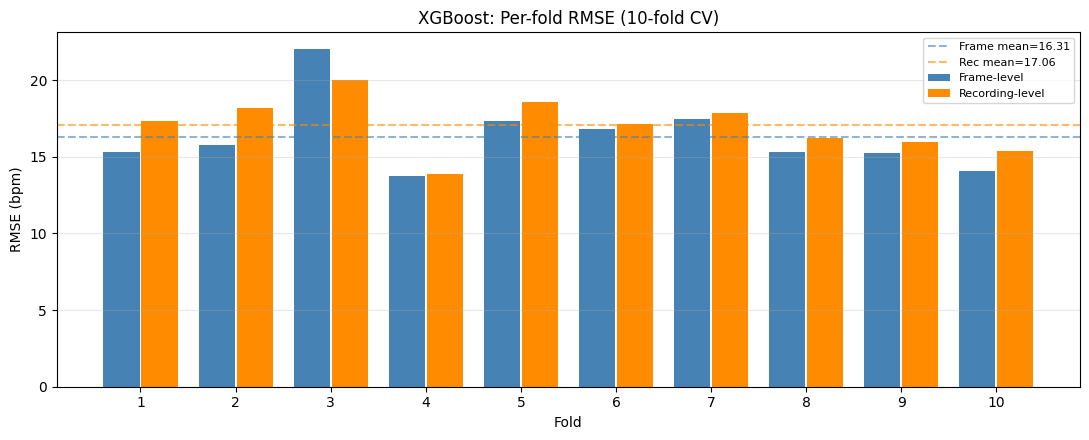

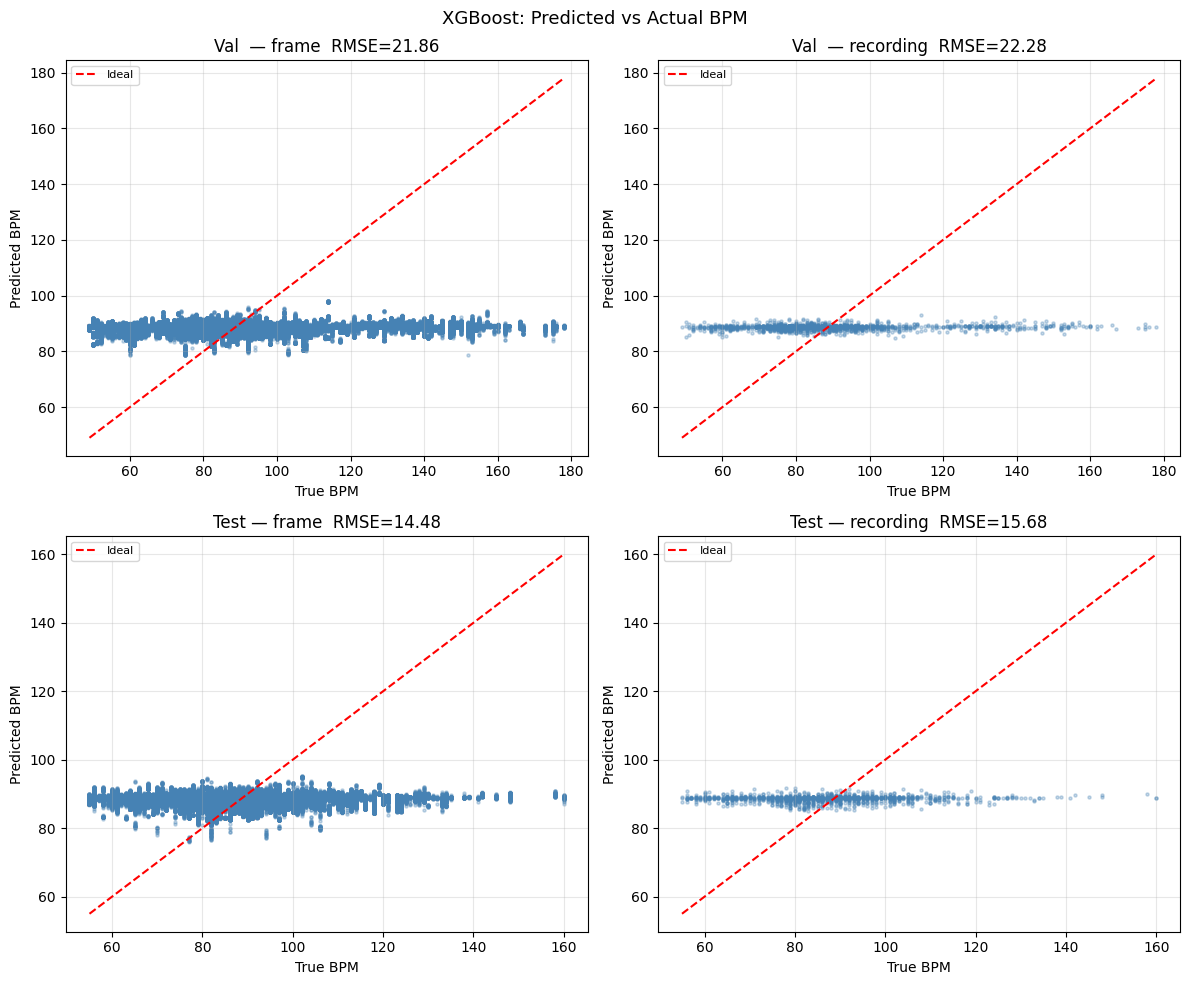

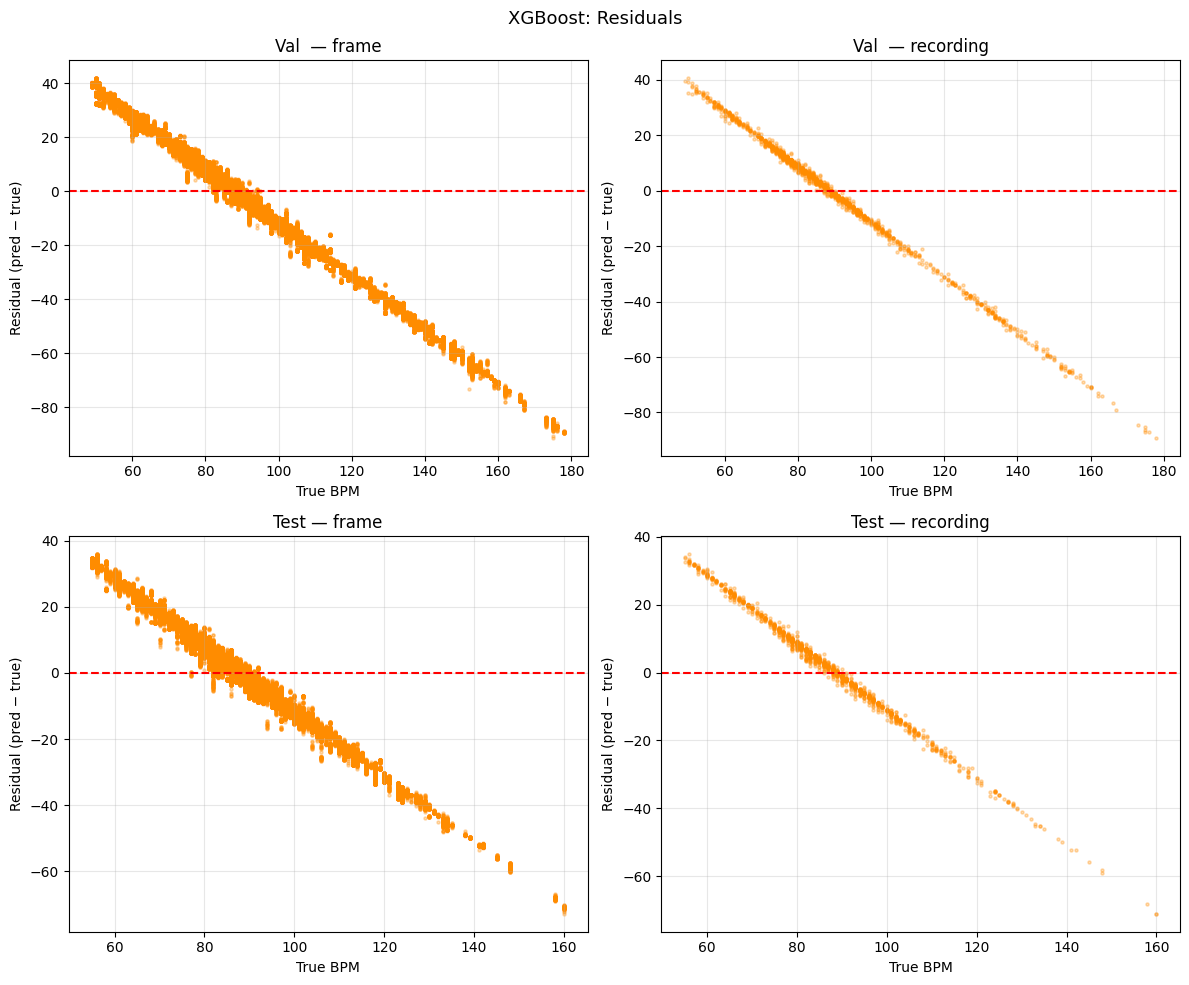

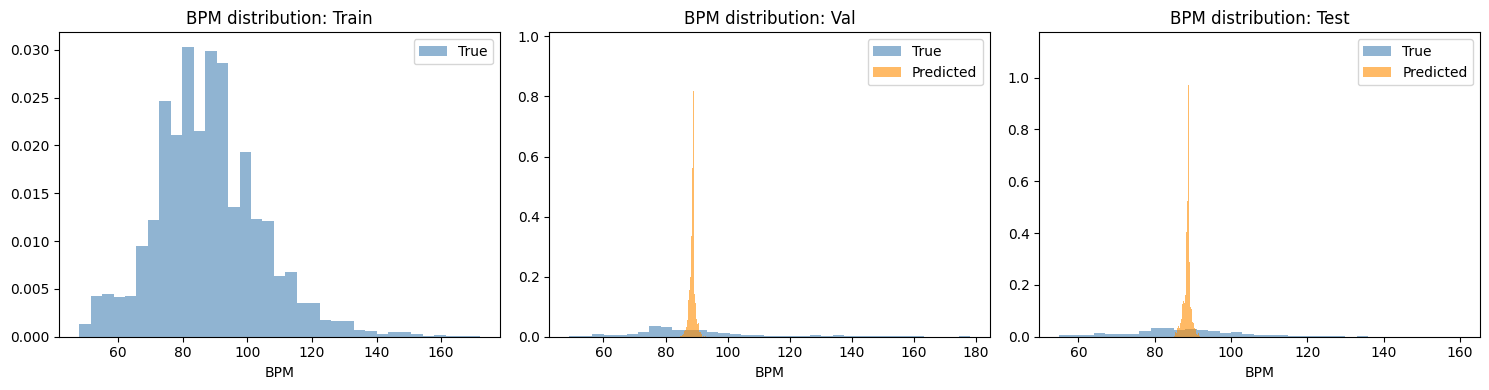

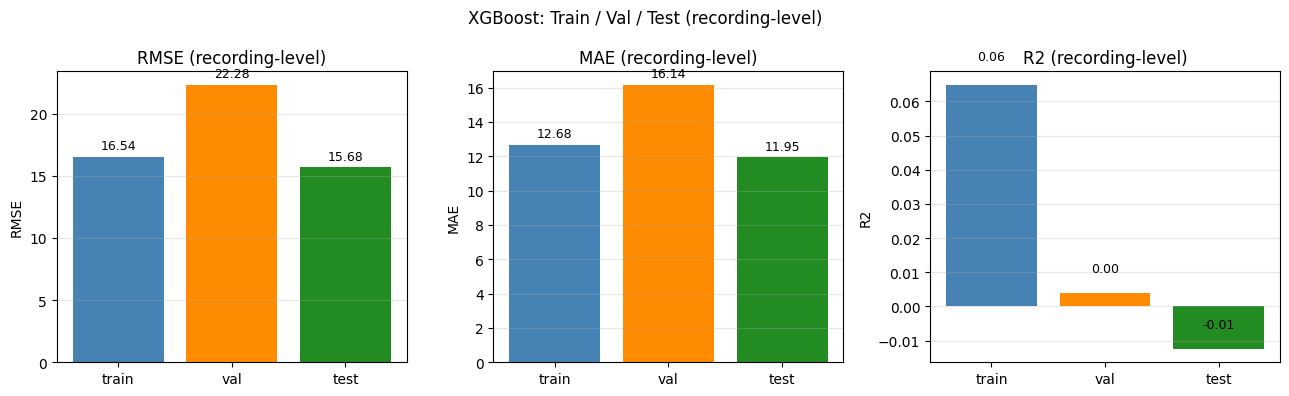

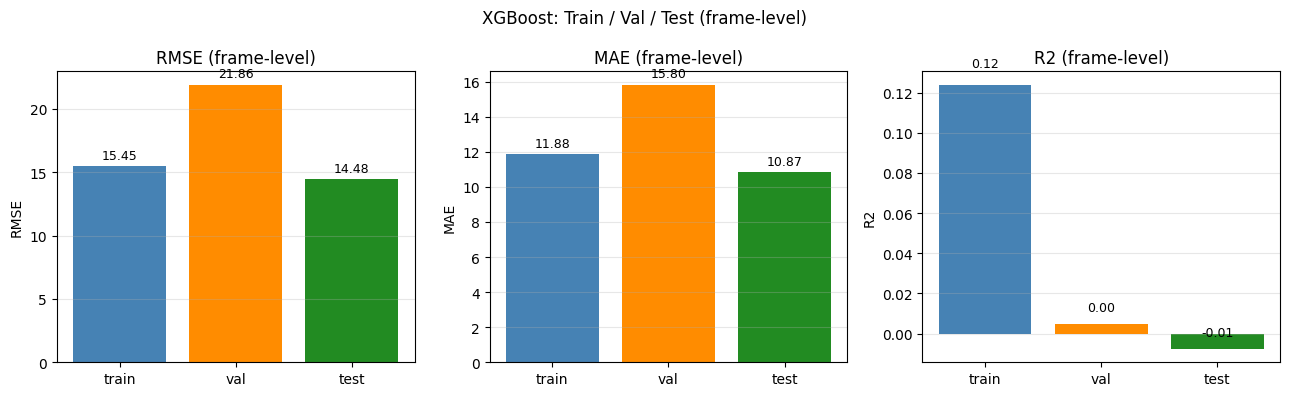

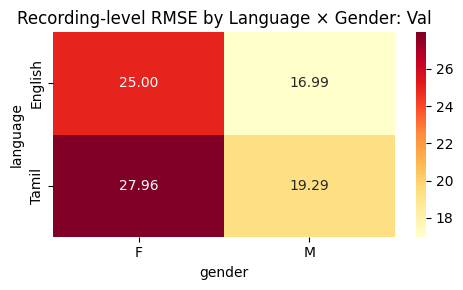

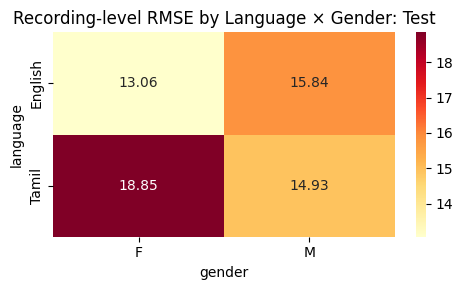

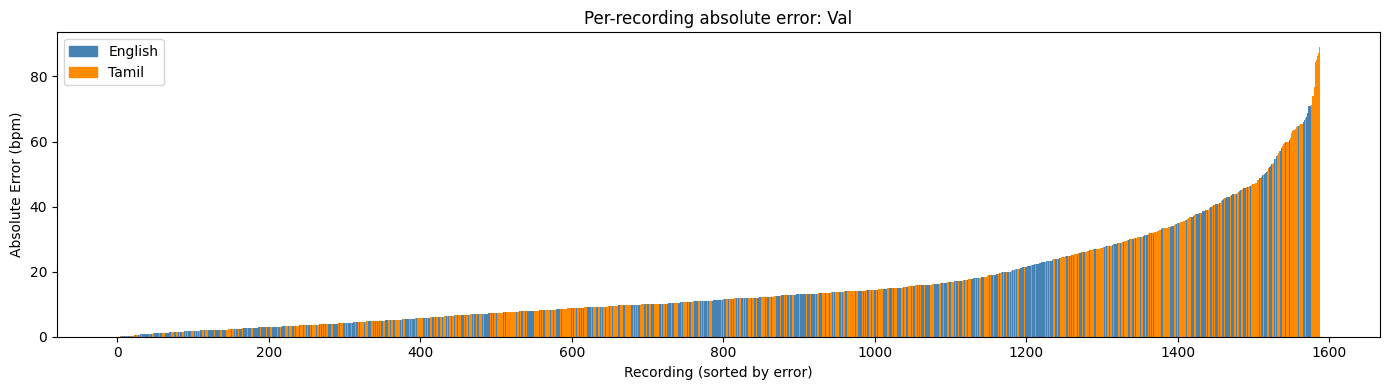

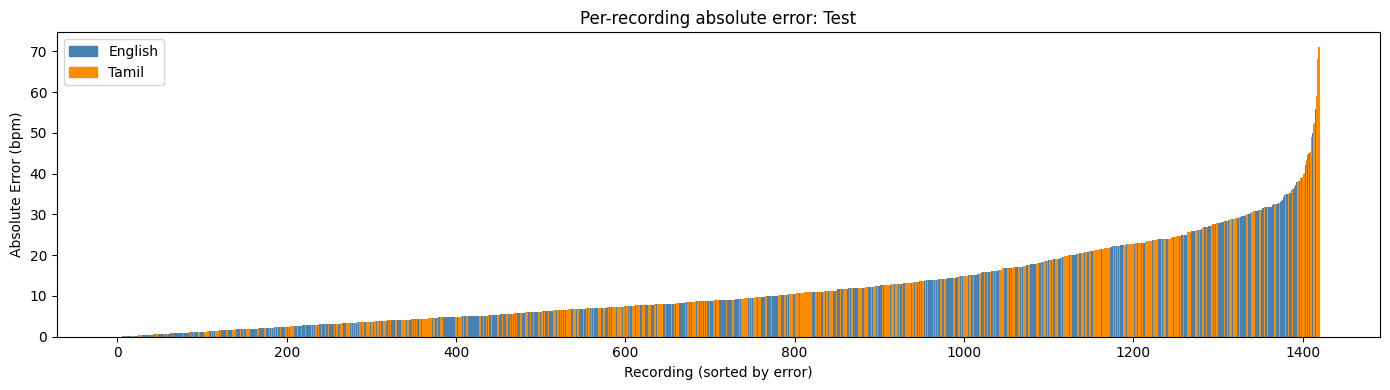

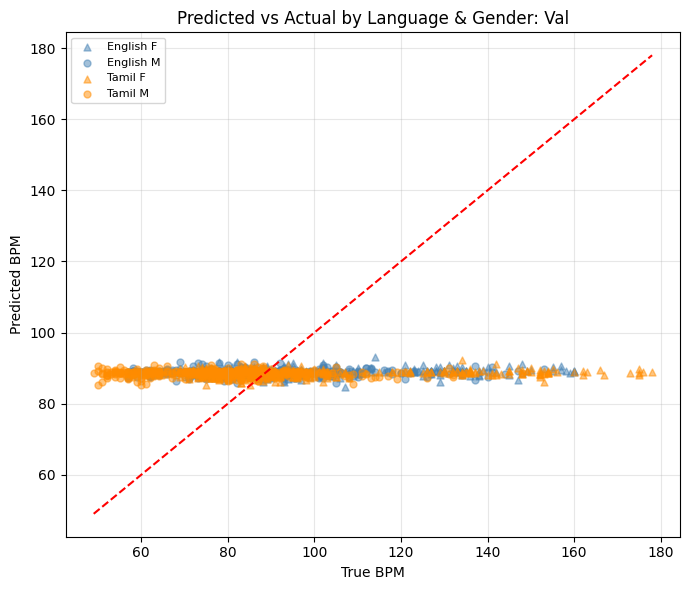

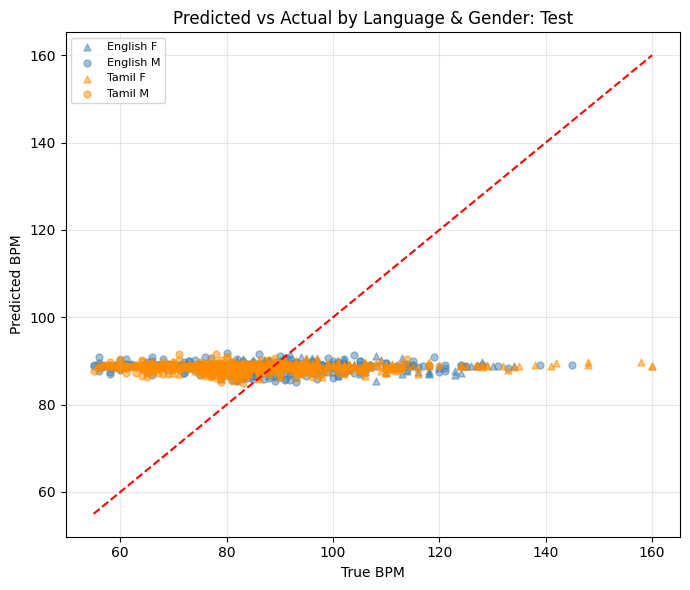

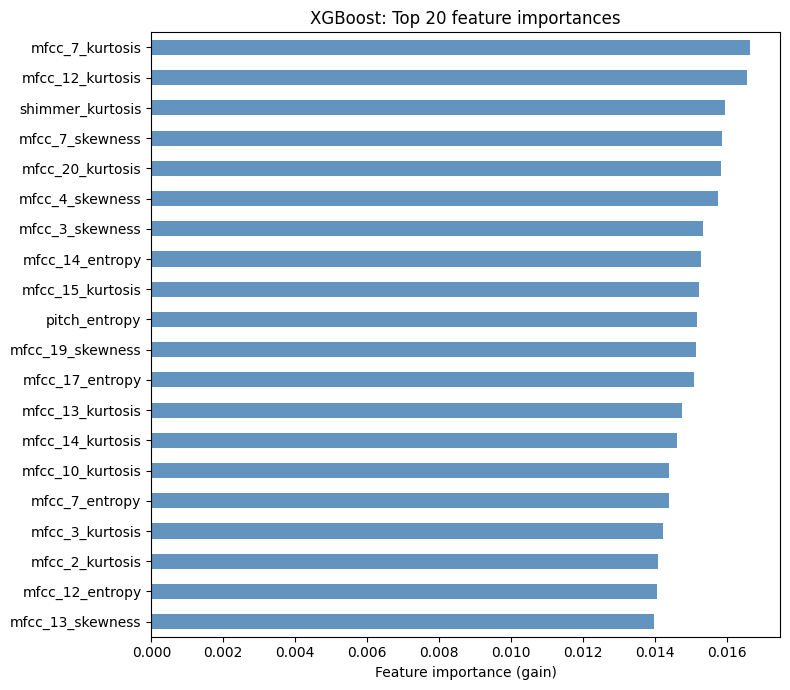

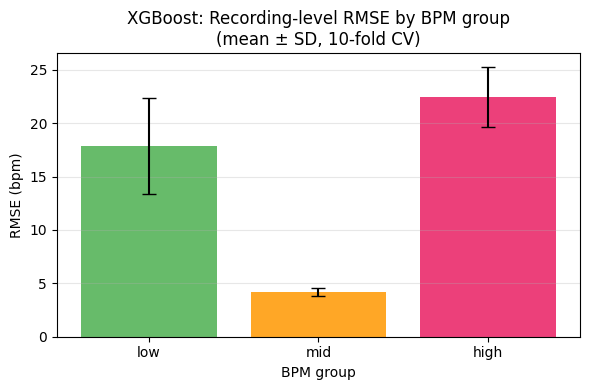


All metrics and plots saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/new_norm


In [35]:
# =============================================================================
# XGBoost — 10-fold CV evaluation + train/val/test reporting
#
# Mirrors the CNN training cell: frame + recording level metrics,
# overall and per language/gender/BPM-group, same plot suite.
# Outputs go to outputs/new_norm/.
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 10

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/new_norm")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/new_norm")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load data ---------------------------------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

X_val        = pd.read_parquet(DATA_DIR / "X_val.parquet").reset_index(drop=True)
y_val        = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns").reset_index(drop=True)
groups_val   = pd.read_parquet(DATA_DIR / "groups_val.parquet").reset_index(drop=True)

X_test       = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)
y_test       = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns").reset_index(drop=True)
groups_test  = pd.read_parquet(DATA_DIR / "groups_test.parquet").reset_index(drop=True)

# --- Best model + params -----------------------------------------------------
with open(OUT_DIR / "xgb_best_params.json") as fh:
    best_params = json.load(fh)
best_params.update({
    "objective": "reg:squarederror", "tree_method": "hist",
    "random_state": RANDOM_STATE, "n_jobs": 1,
})
ref_model = XGBRegressor()
ref_model.load_model(OUT_DIR / "xgb_best.json")

# --- BPM tertile (same boundaries as tuning cell) ----------------------------
bpm_tertile = pd.qcut(
    y_train, q=3, labels=["low", "mid", "high"], duplicates="drop"
).astype(str)
groups_train["bpm_tertile"] = bpm_tertile
groups_train["cv_stratum"]  = (
    groups_train["language"] + "_" +
    groups_train["gender"]   + "_" +
    groups_train["bpm_tertile"]
)

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(
    sgkf.split(X_train,
               y=groups_train["cv_stratum"].values,
               groups=groups_train["speaker_id"].values)
)

# =============================================================================
# HELPER FUNCTIONS  (mirror CNN cell)
# =============================================================================

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    if len(y_true) < 2:
        return {"n": int(len(y_true)), "RMSE": float("nan"),
                "MAE": float("nan"), "R2": float("nan")}
    return {
        "n":    int(len(y_true)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }

def aggregate_to_recording(df_frame):
    return (
        df_frame.groupby("file_name")
        .agg(y_true=("y_true","mean"), y_pred=("y_pred","mean"),
             language=("language","first"), gender=("gender","first"))
        .reset_index()
    )

def make_predictions_df(model, X, y_1d, groups_df):
    return pd.DataFrame({
        "file_name": groups_df["file_name"].values,
        "language":  groups_df["language"].values,
        "gender":    groups_df["gender"].values,
        "y_true":    np.asarray(y_1d, float),
        "y_pred":    model.predict(X).ravel(),
    })

def full_metrics_block(df_frame, tag):
    df_rec = aggregate_to_recording(df_frame)
    out = {}
    for lvl, df in [("frame", df_frame), ("recording", df_rec)]:
        key = f"{tag}_{lvl}"
        out[key] = {"overall": compute_metrics(df["y_true"], df["y_pred"])}
        for col in ["language", "gender"]:
            out[key][col] = {
                str(g): compute_metrics(sub["y_true"], sub["y_pred"])
                for g, sub in df.groupby(col)
            }
    return out, df_rec

def print_comparison_table(all_metrics):
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        for lvl in ["frame", "recording"]:
            key = f"{split}_{lvl}"
            if key not in all_metrics:
                continue
            m = all_metrics[key]["overall"]
            print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  "
                  f"R2={m['R2']:.3f}  n={m['n']}")
            for col in ["language", "gender"]:
                for grp, gm in sorted(all_metrics[key].get(col, {}).items()):
                    print(f"    {col}={grp:8s}: RMSE={gm['RMSE']:.3f}  "
                          f"MAE={gm['MAE']:.3f}  n={gm['n']}")

# --- Plot helpers ------------------------------------------------------------

def plot_scatter(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred, alpha=0.3, s=5, color="steelblue", rasterized=True)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"{title}  RMSE={rmse:.2f}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

def plot_residuals(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred - y_true, alpha=0.3, s=5, color="darkorange", rasterized=True)
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_xlabel("True BPM"); ax.set_ylabel("Residual (pred − true)")
    ax.set_title(title); ax.grid(alpha=0.3)

def plot_fold_rmse(fold_frame_df, fold_record_df, out_path):
    f = fold_frame_df[fold_frame_df["subgroup"] == "overall"].sort_values("fold")
    r = fold_record_df[fold_record_df["subgroup"] == "overall"].sort_values("fold")
    x = np.arange(len(f))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - 0.2, f["RMSE"], width=0.38, label="Frame-level",     color="steelblue")
    ax.bar(x + 0.2, r["RMSE"], width=0.38, label="Recording-level", color="darkorange")
    ax.axhline(f["RMSE"].mean(), color="steelblue",  lw=1.5, ls="--", alpha=0.6,
               label=f"Frame mean={f['RMSE'].mean():.2f}")
    ax.axhline(r["RMSE"].mean(), color="darkorange", lw=1.5, ls="--", alpha=0.6,
               label=f"Rec mean={r['RMSE'].mean():.2f}")
    ax.set_xticks(x); ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold"); ax.set_ylabel("RMSE (bpm)")
    ax.set_title("XGBoost: Per-fold RMSE (10-fold CV)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_bpm_distributions(y_train_true, y_val_true, y_val_pred,
                            y_test_true, y_test_pred, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, true, pred, split in zip(
        axes,
        [y_train_true, y_val_true,  y_test_true],
        [None,          y_val_pred,  y_test_pred],
        ["Train",       "Val",       "Test"],
    ):
        ax.hist(true, bins=35, alpha=0.6, label="True",      color="steelblue", density=True)
        if pred is not None:
            ax.hist(pred, bins=35, alpha=0.6, label="Predicted", color="darkorange", density=True)
        ax.set_title(f"BPM distribution: {split}")
        ax.set_xlabel("BPM"); ax.legend()
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_train_val_test_comparison(all_metrics, level, out_path):
    splits = ["train", "val", "test"]
    colors = ["steelblue", "darkorange", "forestgreen"]
    rmse_v = [all_metrics[f"{s}_{level}"]["overall"]["RMSE"] for s in splits]
    mae_v  = [all_metrics[f"{s}_{level}"]["overall"]["MAE"]  for s in splits]
    r2_v   = [all_metrics[f"{s}_{level}"]["overall"]["R2"]   for s in splits]
    x = np.arange(len(splits))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, vals, name in zip(axes, [rmse_v, mae_v, r2_v], ["RMSE", "MAE", "R2"]):
        ax.bar(x, vals, color=colors)
        ax.set_xticks(x); ax.set_xticklabels(splits)
        ax.set_ylabel(name); ax.set_title(f"{name} ({level}-level)"); ax.grid(axis="y", alpha=0.3)
        for i, v in enumerate(vals):
            ax.text(i, v + abs(v)*0.02 + 0.005, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    fig.suptitle(f"XGBoost: Train / Val / Test ({level}-level)", fontsize=12)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_confusion_by_subgroup(df_rec, tag, out_path):
    rows = []
    for (lang, gen), sub in df_rec.groupby(["language", "gender"]):
        rows.append({"language": lang, "gender": gen,
                     "RMSE": compute_metrics(sub["y_true"].values,
                                             sub["y_pred"].values)["RMSE"]})
    pivot = pd.DataFrame(rows).pivot(index="language", columns="gender", values="RMSE")
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"Recording-level RMSE by Language × Gender: {tag}")
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def inspect_per_recording(df_rec, tag, out_path):
    df = df_rec.copy()
    df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()
    df_s = df.sort_values("abs_error").reset_index(drop=True)
    cmap = {"English": "steelblue", "Tamil": "darkorange"}
    colors = df_s["language"].map(cmap).fillna("grey")
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(np.arange(len(df_s)), df_s["abs_error"], color=colors, width=1.0)
    ax.set_xlabel("Recording (sorted by error)"); ax.set_ylabel("Absolute Error (bpm)")
    ax.set_title(f"Per-recording absolute error: {tag}")
    handles = [mpatches.Patch(color=c, label=l) for l, c in cmap.items()]
    ax.legend(handles=handles)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_by_lang_gender(df_rec, tag, out_path):
    lang_colors = {"English": "steelblue", "Tamil": "darkorange"}
    gender_markers = {"M": "o", "F": "^"}
    fig, ax = plt.subplots(figsize=(7, 6))
    for (lang, gen), sub in df_rec.groupby(["language", "gender"]):
        ax.scatter(sub["y_true"], sub["y_pred"],
                   color=lang_colors.get(lang, "grey"),
                   marker=gender_markers.get(gen, "s"),
                   alpha=0.5, s=25, label=f"{lang} {gen}")
    lo = min(df_rec["y_true"].min(), df_rec["y_pred"].min())
    hi = max(df_rec["y_true"].max(), df_rec["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
    ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"Predicted vs Actual by Language & Gender: {tag}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

# =============================================================================
# 10-FOLD CV LOOP
# =============================================================================
SUBGROUPS = ["gender", "language", "bpm_tertile"]
fold_frame_rows, fold_record_rows = [], []

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    meta_va    = groups_train.iloc[va_idx].reset_index(drop=True)

    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    # Frame-level
    for col in (["overall"] + SUBGROUPS):
        if col == "overall":
            m = compute_metrics(y_va.values, y_pred)
            fold_frame_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **m})
        else:
            for lv, mask_idx in meta_va.groupby(col).groups.items():
                idx = np.asarray(mask_idx)
                m = compute_metrics(y_va.values[idx], y_pred[idx])
                fold_frame_rows.append({"fold": fold_idx, "subgroup": col, "level": str(lv), **m})

    # Recording-level
    rec = pd.DataFrame({
        "file_name":   meta_va["file_name"].values,
        "y_true":      y_va.values,
        "y_pred":      y_pred,
        "gender":      meta_va["gender"].values,
        "language":    meta_va["language"].values,
        "bpm_tertile": meta_va["bpm_tertile"].values,
    }).groupby("file_name").agg(
        y_true=("y_true","mean"), y_pred=("y_pred","mean"),
        gender=("gender","first"), language=("language","first"),
        bpm_tertile=("bpm_tertile","first")
    ).reset_index()

    ov_r = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    fold_record_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **ov_r})
    for col in SUBGROUPS:
        for lv, grp in rec.groupby(col):
            m = compute_metrics(grp["y_true"].values, grp["y_pred"].values)
            fold_record_rows.append({"fold": fold_idx, "subgroup": col, "level": str(lv), **m})

    ov_f = next(r for r in reversed(fold_frame_rows)
                if r["subgroup"] == "overall" and r["fold"] == fold_idx)
    print(f"Fold {fold_idx:2d} | Frame RMSE={ov_f['RMSE']:.3f}  MAE={ov_f['MAE']:.3f}  "
          f"| Recording RMSE={ov_r['RMSE']:.3f}  MAE={ov_r['MAE']:.3f}  n={ov_r['n']}")

fold_frame_df  = pd.DataFrame(fold_frame_rows)
fold_record_df = pd.DataFrame(fold_record_rows)

def _summarise(df):
    return (df.groupby(["subgroup","level"])[["RMSE","MAE","R2"]]
              .agg(["mean","std"]).round(3))

frame_summary  = _summarise(fold_frame_df)
record_summary = _summarise(fold_record_df)

print("\n=== Frame-level CV summary (mean ± SD) ===")
print(frame_summary.to_string())
print("\n=== Recording-level CV summary (mean ± SD) ===")
print(record_summary.to_string())

# =============================================================================
# TRAIN / VAL / TEST EVALUATION WITH SAVED BEST MODEL
# =============================================================================
df_train_frame = make_predictions_df(ref_model, X_train, y_train, groups_train)
df_val_frame   = make_predictions_df(ref_model, X_val,   y_val,   groups_val)
df_test_frame  = make_predictions_df(ref_model, X_test,  y_test,  groups_test)

train_results, train_rec = full_metrics_block(df_train_frame, "train")
val_results,   val_rec   = full_metrics_block(df_val_frame,   "val")
test_results,  test_rec  = full_metrics_block(df_test_frame,  "test")
all_metrics = {**train_results, **val_results, **test_results}

print("\n=== XGBoost performance summary ===")
print_comparison_table(all_metrics)

# =============================================================================
# SAVE METRICS + PREDICTIONS
# =============================================================================
with open(OUT_DIR / "xgb_all_metrics.json", "w") as fh:
    json.dump(all_metrics, fh, indent=2)

val_rec.to_csv(OUT_DIR / "xgb_val_recording_predictions.csv",  index=False)
test_rec.to_csv(OUT_DIR / "xgb_test_recording_predictions.csv", index=False)
fold_frame_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_frame.csv",     index=False)
fold_record_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_recording.csv", index=False)
frame_summary.to_csv(OUT_DIR  / "xgb_cv_summary_frame.csv")
record_summary.to_csv(OUT_DIR / "xgb_cv_summary_recording.csv")

# =============================================================================
# PLOTS
# =============================================================================

# 1. Per-fold RMSE (frame vs recording)
plot_fold_rmse(fold_frame_df, fold_record_df,
               OUT_DIR / "xgb_perfold_rmse.png")

# 2. Scatter 2×2: val frame | val recording | test frame | test recording
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_scatter(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  — frame",      axes[0,0])
plot_scatter(val_rec["y_true"],       val_rec["y_pred"],        "Val  — recording",  axes[0,1])
plot_scatter(df_test_frame["y_true"], df_test_frame["y_pred"], "Test — frame",      axes[1,0])
plot_scatter(test_rec["y_true"],      test_rec["y_pred"],       "Test — recording",  axes[1,1])
fig.suptitle("XGBoost: Predicted vs Actual BPM", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_scatter_plots.png", dpi=200)
plt.show(); plt.close(fig)

# 3. Residuals 2×2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_residuals(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  — frame",      axes[0,0])
plot_residuals(val_rec["y_true"],       val_rec["y_pred"],        "Val  — recording",  axes[0,1])
plot_residuals(df_test_frame["y_true"], df_test_frame["y_pred"], "Test — frame",      axes[1,0])
plot_residuals(test_rec["y_true"],      test_rec["y_pred"],       "Test — recording",  axes[1,1])
fig.suptitle("XGBoost: Residuals", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_residual_plots.png", dpi=200)
plt.show(); plt.close(fig)

# 4. BPM distributions
y_val_pred_rec  = val_rec["y_pred"].values
y_test_pred_rec = test_rec["y_pred"].values
plot_bpm_distributions(
    y_train.values, val_rec["y_true"].values,  y_val_pred_rec,
    test_rec["y_true"].values, y_test_pred_rec,
    OUT_DIR / "xgb_bpm_distributions.png",
)

# 5–6. Train/val/test bar comparisons
plot_train_val_test_comparison(all_metrics, "recording", OUT_DIR / "xgb_train_val_test_rmse_recording.png")
plot_train_val_test_comparison(all_metrics, "frame",     OUT_DIR / "xgb_train_val_test_rmse_frame.png")

# 7–8. Heatmap language × gender
plot_confusion_by_subgroup(val_rec,  "Val",  OUT_DIR / "xgb_val_heatmap_lang_gender.png")
plot_confusion_by_subgroup(test_rec, "Test", OUT_DIR / "xgb_test_heatmap_lang_gender.png")

# 9–10. Per-recording sorted error
inspect_per_recording(val_rec,  "Val",  OUT_DIR / "xgb_val_per_recording_error.png")
inspect_per_recording(test_rec, "Test", OUT_DIR / "xgb_test_per_recording_error.png")

# 11–12. Scatter by language + gender
plot_by_lang_gender(val_rec,  "Val",  OUT_DIR / "xgb_val_by_lang_gender.png")
plot_by_lang_gender(test_rec, "Test", OUT_DIR / "xgb_test_by_lang_gender.png")

# 13. Feature importance (top 20)
importances = pd.Series(
    ref_model.feature_importances_, index=X_train.columns
).nlargest(20).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color="steelblue", alpha=0.85)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost: Top 20 feature importances")
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_feature_importance.png", dpi=200)
plt.show(); plt.close(fig)

# 14. RMSE by BPM group (CV folds)
bpm_grp = (fold_record_df[fold_record_df["subgroup"] == "bpm_tertile"]
           .groupby("level")["RMSE"].agg(["mean","std"])
           .reindex(["low","mid","high"]).reset_index())
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bpm_grp["level"], bpm_grp["mean"], yerr=bpm_grp["std"],
       capsize=5, color=["#4CAF50","#FF9800","#E91E63"], alpha=0.85)
ax.set_xlabel("BPM group"); ax.set_ylabel("RMSE (bpm)")
ax.set_title("XGBoost: Recording-level RMSE by BPM group\n(mean ± SD, 10-fold CV)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_rmse_by_bpm.png", dpi=200)
plt.show(); plt.close(fig)

print(f"\nAll metrics and plots saved to {OUT_DIR}")
